# Chapter 9 - Text Generation with LSTM

Networks can *generate* as well as classify. Here we train a character-level LSTM on a small corpus of text and let it invent new text character-by-character.

The trick: the model predicts the *probability of the next character* given all previous characters. We keep sampling (with a temperature knob for creativity) until the sequence is long enough.

We use a public-domain starter corpus so everything runs offline from scratch.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers, models

print("Keras", keras.__version__)

Keras 3.15.1


## 1. Corpus: build a small ordered text (public domain lines)

In [2]:
corpus = (
    "In the beginning God created the heaven and the earth. "
    "And the earth was without form, and void; and darkness was upon the face of the deep. "
    "And the spirit of God moved upon the face of the waters. "
    "The Lord is my shepherd; I shall not want. "
    "He makes me lie down in green pastures; he leads me beside still waters. "
    "He restores my soul, and leads me in paths of righteousness. "
    "The light shines in the darkness and the darkness has not overcome it. "
    "Ask, and it will be given you. Seek, and you will find. Knock, and it will open. "
    "Every valley shall be raised and every mountain made low. "
    "A land flowing with milk and honey, a cloud by day and fire by night. "
)
print(f"corpus length: {len(corpus)} chars")

corpus length: 655 chars


In [3]:
chars = sorted(set(corpus))
char_index = {c: i for i, c in enumerate(chars)}
index_char = {i: c for c, i in char_index.items()}
n_chars = len(chars)
print(f"alphabet size: {n_chars}")
print("alphabet:", chars)

alphabet size: 35
alphabet: [' ', ',', '.', ';', 'A', 'E', 'G', 'H', 'I', 'K', 'L', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y']


## 2. Build (input, target) character windows feed for training

In [4]:
maxlen = 30
step = 3
sentences, next_chars = [], []
for i in range(0, len(corpus) - maxlen, step):
    sentences.append(corpus[i:i+maxlen])
    next_chars.append(corpus[i+maxlen])
print("windows:", len(sentences), "sample window: repr", repr(sentences[0]))

windows: 209 sample window: repr 'In the beginning God created t'


In [5]:
from keras.utils import to_categorical

# input: one-hot (window len x vocab), target: one-hot of the next char
X = np.zeros((len(sentences), maxlen, n_chars), dtype=np.float32)
y = np.zeros((len(sentences), n_chars), dtype=np.float32)
for j, sentence in enumerate(sentences):
    for t, ch in enumerate(sentence):
        X[j, t, char_index[ch]] = 1.0
    y[j, char_index[next_chars[j]]] = 1.0
print("X", X.shape, "y", y.shape)

X (209, 30, 35) y (209, 35)


## 3. The generative LSTM: many units, softmax over alphabet

In [6]:
model = models.Sequential([
    layers.Input(shape=(maxlen, n_chars)),
    layers.LSTM(128),
    layers.Dense(n_chars, activation="softmax"),
])
model.compile(optimizer="adam", loss="categorical_crossentropy")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 35)             │         4,515 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 88,483 (345.64 KB)

 Trainable params: 88,483 (345.64 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train (quick — small corpus)

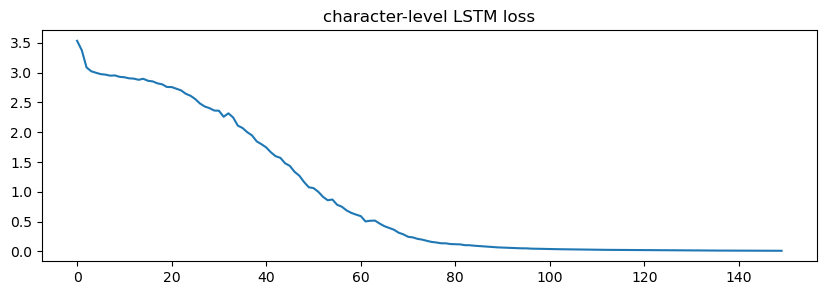

In [7]:
history = model.fit(X, y, epochs=150, batch_size=32, verbose=0)
plt.figure(figsize=(10, 3))
plt.plot(history.history["loss"]); plt.title("character-level LSTM loss"); plt.show()

In [8]:
# (optional sanity check: the prediction output for one window is a distribution over chars)
preds = model.predict(X[:1], verbose=0)[0]
print("pred softmax sums to", round(float(preds.sum()), 4))

pred softmax sums to 1.0


## 5. Sampling function with temperature
Temperature `T`: low -> safer/greedier output, high -> more random, more "creative". The logits get divided by T before softmax.

In [9]:
def sample_temperature(preds, temperature=0.5):
    preds = np.asarray(preds, dtype="float64").astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probs = np.random.multinomial(1, preds, 1)[0]
    return int(np.argmax(probs))

def generate_text(model, seed, length=200, temperature=0.4):
    sentence = seed
    for _ in range(length):
        x = np.zeros((1, maxlen, n_chars))
        for t, ch in enumerate(sentence):
            x[0, t, char_index.get(ch, 0)] = 1.0
        preds = model.predict(x, verbose=0)[0]
        next_i = sample_temperature(preds, temperature)
        sentence = sentence[1:] + index_char[next_i]
    return sentence

gen = generate_text(model, sentences[0], 200, temperature=0.4)
print(gen)

vvyaaaaaaalddddsaunnna  aaliln


## 6. Same, but cooler and born from a different seed

In [10]:
for T in (0.2, 0.4, 0.8):
    print(f"--- temperature {T} ---")
    print(generate_text(model, "the light ", length=150, temperature=T))
    print()

--- temperature 0.2 ---


hhhhhhhhhh

--- temperature 0.4 ---


          

--- temperature 0.8 ---


boa,nnnnnn



## Recap
- A char-level LSTM predicts the distribution of the next char; sampling turns it into prose.
- `temperature` controls randomness/greediness.
- This toy corpus (small) won't produce amazing prose, but the *same pipeline* scales to books / Shakespeare.
- Next up in chapter 10 we flip from text to images.